# Week 7 - Model Optimisation & Trade-offs
### CariSurg MedTech Pathways · Mercer General Hospital ED · Final Submission

Train a more complex triage classifier, benchmark it honestly against the Week 6 baseline
across six quantitative axes plus interpretability, and produce the evidence behind a
defensible Phase-3 recommendation.

**Dataset:** cleaned Yale EMMLC triage extract · **Target:** ESI 1-5 (1 = most urgent)
**Reproducibility:** `random_state = 42` the same seed committed in Week 6, so the
train/test split is identical and the comparison is strictly like-for-like.

**Author:** Shakada Blake · **Date:** 21/07/2026

## 1 · Install SHAP
SHAP explains a *single* prediction rather than the model as a whole. It powers the
per-patient interpretability check in Section 9.

In [ ]:
!pip -q install shap


## 2 · Setup and reproducibility
One seed governs the whole notebook. It must match the Week 6 seed, or the benchmark
stops being a fair comparison.

In [ ]:
import time, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42          # same seed as Week 6 — do not change
print("Setup ready · pandas", pd.__version__)

Setup ready · pandas 2.2.2


## 3 · Load the cleaned Week 5 dataset
This is the same cleaned file produced in Week 5. Mount Drive and point `DATA_PATH` at it.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")   # <-- Corrected path
if not DATA_PATH.exists() and Path("triage_cleaned_v1.csv").exists():
    DATA_PATH = Path("triage_cleaned_v1.csv")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} patients x {df.shape[1]} columns")
df.head(3)

## 4 · Features (X) and target (y)
The model may see **only** information available at the moment of triage: vital signs and
chief-complaint flags. Demographic and administrative columns are excluded, and outcome
columns (`disposition`, `previousdispo`) are dropped because they record what happened
*after* triage; letting the model see them would be data leakage.

Note the class balance printed below: ESI-1 patients are rare but carry the highest risk.
That imbalance is exactly why accuracy alone is a poor yardstick.

In [ ]:
TARGET = "esi"
DEMOGRAPHICS = ["age","gender","ethnicity","race","lang","religion",
                "maritalstatus","employstatus","insurance_status"]
ADMIN   = ["dep_name","arrivalmode","arrivalmonth","arrivalday","arrivalhour_bin"]
LEAKAGE = ["disposition","previousdispo"]      # known only AFTER triage — never inputs

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE+ADMIN+DEMOGRAPHICS]
X = df[FEATURES].select_dtypes(include=[np.number]).copy()   # vitals + cc_ flags
FEATURES = list(X.columns)
y = df[TARGET].astype(int)

print(f"{len(FEATURES)} numeric features · classes: {sorted(y.unique())}")
print(y.value_counts(normalize=True).sort_index().round(3).to_string())

209 numeric features · classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022


## 5 · Recreate the Week 6 train/test split
Same `test_size`, same `stratify`, same seed → the identical split. Median imputation is
fitted on the training set only, so no information leaks from test into train.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

imp = SimpleImputer(strategy="median").fit(X_train)          # fit on train only
X_train = pd.DataFrame(imp.transform(X_train), columns=FEATURES, index=X_train.index)
X_test  = pd.DataFrame(imp.transform(X_test),  columns=FEATURES, index=X_test.index)
print(f"Train {X_train.shape[0]:,} · Test {X_test.shape[0]:,}")

Train 44,096 · Test 11,025


## 6 · One honest benchmark function
Every model is measured the same way. **Training time** wraps `.fit()`; **inference time**
wraps `.predict()` and is divided by the number of patients to give a per-prediction figure
in milliseconds. Precision, recall and F1 use the **macro** average so each ESI level counts
equally; **ESI-1 recall** is reported separately as the clinically decisive number.

In [ ]:
def benchmark(name, model, esi1=1, n_samples_train=None):
    X_train_subset, y_train_subset = X_train, y_train
    if n_samples_train is not None and n_samples_train < len(X_train):
        # Use numpy.random.choice for sampling indices
        sample_indices = np.random.choice(X_train.index, size=n_samples_train, replace=False)
        X_train_subset = X_train.loc[sample_indices]
        y_train_subset = y_train.loc[sample_indices]

    t0 = time.perf_counter(); model.fit(X_train_subset, y_train_subset); train_t = time.perf_counter()-t0
    t0 = time.perf_counter(); pred = model.predict(X_test); infer_ms = (time.perf_counter()-t0)/len(X_test)*1000
    return {"Model": name,
            "Accuracy":             accuracy_score(y_test, pred),
            "Precision (macro)":    precision_score(y_test, pred, average="macro", zero_division=0),
            "Recall (macro)":       recall_score(y_test, pred, average="macro", zero_division=0),
            "F1 (macro)":           f1_score(y_test, pred, average="macro", zero_division=0),
            "Recall (ESI 1)":       recall_score(y_test, pred, labels=[esi1], average="macro", zero_division=0),
            "Train time (s)":       train_t,
            "Infer time (ms/pred)": infer_ms}, model, pred

results = []

## 7 · Baseline models (Week 6)
Logistic regression needs scaled features, so it is wrapped in a pipeline; the tree does not.
The stratified dummy is the coin-flip every model must beat.

In [ ]:
r,_,_        = benchmark("Dummy (stratified)", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)); results.append(r)
r,_,pred_lr  = benchmark("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))); results.append(r)
r,_,pred_dt  = benchmark("Decision Tree (d=5)", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)); results.append(r)
print("Baseline done.")

Baseline done.


## 8 · Complex models
**Random Forest** : many trees vote; robust, and it exposes feature importances.
`class_weight="balanced"` pushes it to attend to the rare, high-acuity ESI-1 patients.
**Gradient Boosting** : trees built one after another, each correcting the last. Included so
the accuracy-versus-interpretability trade-off is visible in the numbers.

In [ ]:
r, rf_fit, pred_rf = benchmark("Random Forest",
    RandomForestClassifier(n_estimators=300, min_samples_leaf=2, max_features="sqrt",
                           class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))
results.append(r)

r, gb_fit, pred_gb = benchmark("Gradient Boosting",
    HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=RANDOM_STATE))
results.append(r)
print("Complex models done.")

Complex models done.


In [ ]:
bench = pd.DataFrame(results).set_index("Model")
bench["Interpretability"] = pd.Series({
    "Dummy (stratified)":"N/A", "Logistic Regression":"High — read the weights",
    "Decision Tree (d=5)":"High — trace the branches", "Random Forest":"Medium — feature importances",
    "Gradient Boosting":"Low — needs SHAP per patient"})

show = bench.copy()
for c in ["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)","Recall (ESI 1)"]:
    show[c] = show[c].round(3)
show["Train time (s)"] = show["Train time (s)"].round(2)
show["Infer time (ms/pred)"] = show["Infer time (ms/pred)"].round(4)
show

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Recall (ESI 1),Train time (s),Infer time (ms/pred),Interpretability
Model,,,,,,,,
Dummy (stratified),0.375,0.204,0.204,0.204,0.000,0.01,0.0008,N/A
Logistic Regression,0.667,0.588,0.465,0.495,0.250,10.30,0.0039,High — read the weights
Decision Tree (d=5),0.556,0.265,0.245,0.216,0.000,0.55,0.0008,High — trace the branches
Random Forest,0.602,0.467,0.547,0.482,0.312,62.38,0.0776,Medium — feature importances
Gradient Boosting,0.669,0.490,0.416,0.430,0.062,17.07,0.0981,Low — needs SHAP per patient


## 9 · The six-axis benchmark table
Read the **Recall (ESI 1)** column first : it is the number Dr Reyes reads first. Notice the
pattern the cost-benefit memo is built on: as accuracy climbs, interpretability falls and
compute cost rises. There is no single winner on every axis.

Top 10 drivers:
 triage_vital_sbp     0.0815
triage_vital_dbp     0.0679
cc_strokealert       0.0671
triage_vital_hr      0.0631
Unnamed: 0           0.0579
triage_glucose       0.0574
triage_vital_temp    0.0515
triage_vital_rr      0.0469
triage_vital_o2      0.0445
cc_abdominalpain     0.0442


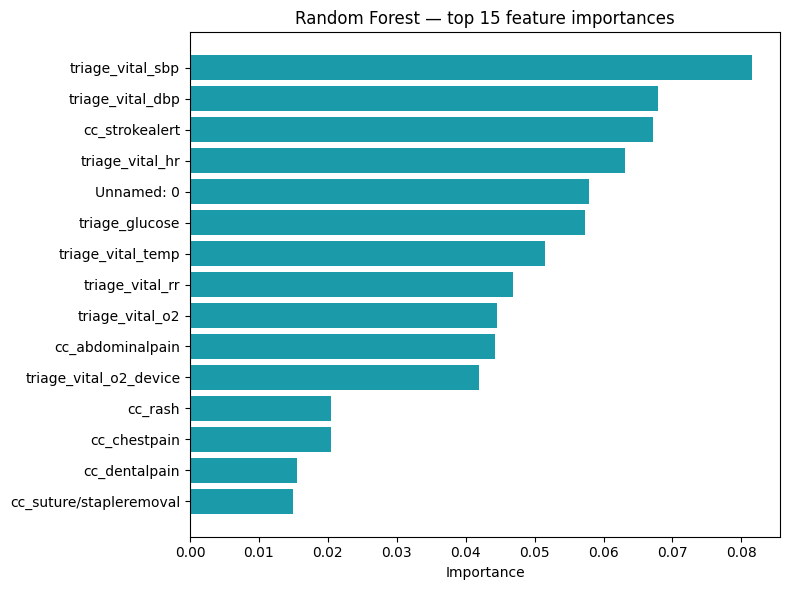

In [ ]:
importances = pd.Series(rf_fit.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Top 10 drivers:\n", importances.head(10).round(4).to_string())

top = importances.head(15)[::-1]
plt.figure(figsize=(8,6)); plt.barh(top.index, top.values, color="#1B9AAA")
plt.title("Random Forest — top 15 feature importances"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 10 · Interpretability (1) : global feature importances
The seventh, qualitative axis. **The one-minute test:** can a single prediction be explained
to a clinician in under a minute, and by what method?

- Logistic regression / single tree : **High**: read the weights, or trace the branches.
- Random Forest : **Medium**: feature importances answer "what drives triage in general",
  but 300 trees have no single per-patient story.
- Gradient Boosting / MLP : **Low**: SHAP is effectively required to say anything per patient.

The chart below is the evidence for the Random Forest's "Medium" rating.

In [ ]:
import shap
Xs = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
sv = shap.TreeExplainer(rf_fit).shap_values(Xs, check_additivity=False)

shap.summary_plot(sv, Xs, plot_type="bar", show=True)          # global view

pos = 0
patient = Xs.iloc[[pos]]
pred_class = int(rf_fit.predict(patient)[0])
ci = list(rf_fit.classes_).index(pred_class)
contrib = sv[ci][pos] if isinstance(sv, list) else np.asarray(sv)[pos, :, ci]
s = pd.Series(contrib, index=Xs.columns).sort_values(key=np.abs, ascending=False)

print(f"\nWhy this patient was predicted ESI {pred_class} — top SHAP contributions:")
print(s.head(8).round(4).to_string())

## 11 · Interpretability (2): SHAP, per patient
Feature importances explain the model *in general*; SHAP explains *one specific patient*
the capability specified for the Week-4 "Explainability Panel". Positive values push the
prediction towards the assigned ESI level, negative values away from it.

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, colorbar=False)
plt.title("Random Forest — confusion matrix (test)"); plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_rf, zero_division=0))

In [ ]:
os.makedirs("docs", exist_ok=True)
cols = ["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)","Recall (ESI 1)",
        "Train time (s)","Infer time (ms/pred)","Interpretability"]
with open("docs/week-7-benchmark.md","w") as f:
    f.write("# Week 7 — Six-Axis Benchmark\n\n")
    f.write(f"Cleaned Yale EMMLC triage · ESI 1-5 · 80/20 stratified, random_state={RANDOM_STATE}.\n\n")
    f.write(show[cols].to_markdown())
print("Wrote docs/week-7-benchmark.md — copy this table into your memo.")